# Week 8 — SVM Experiments

Support Vector Machines find the maximum-margin hyperplane separating classes.
The **kernel trick** maps features into a higher-dimensional space implicitly,
allowing non-linear decision boundaries without computing the mapping explicitly.

This notebook covers:
- **Linear SVM** — baseline, no kernel trick
- **RBF (Gaussian) kernel SVM** — most common choice; infinite-dimensional feature space
- **Polynomial kernel SVM** — degree-d polynomial feature interactions
- **Hyperparameter tuning** — C (regularisation) and gamma (RBF width) via cross-validated grid search
- **Comparison** of all three kernels against the best models so far

In [1]:
import sys, os, time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sys.path.insert(0, os.path.abspath('..'))

from minilearn.preprocessing import StandardScaler, train_test_split
from minilearn.metrics import accuracy_score, f1_score, confusion_matrix, classification_report

from sklearn.svm     import SVC, LinearSVC
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.metrics import accuracy_score as sk_acc

sns.set_theme(style='whitegrid')
RANDOM_STATE  = 42
EMOTION_ORDER = ['neutral','calm','happy','sad','angry','fearful','disgust','surprised']

## 1. Load, Split, Scale

In [2]:
df = pd.read_csv('../outputs/features.csv')
LABEL_COLS   = ['filename','emotion','emotion_id','actor','gender','channel']
feature_cols = [c for c in df.columns if c not in LABEL_COLS]

X_raw = df[feature_cols].values
y     = df['emotion'].values

X_train, X_test, y_train, y_test = train_test_split(
    X_raw, y, test_size=0.20, random_state=RANDOM_STATE
)

scaler    = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s  = scaler.transform(X_test)

print(f'Train: {X_train_s.shape}   Test: {X_test_s.shape}')

Train: (1961, 194)   Test: (491, 194)


## 2. Kernel Overview

| Kernel | Formula | Key hyperparameters |
|--------|---------|--------------------|
| Linear | $K(x,x') = x^\top x'$ | C |
| RBF | $K(x,x') = \exp(-\gamma \|x - x'\|^2)$ | C, γ |
| Polynomial | $K(x,x') = (\gamma\, x^\top x' + r)^d$ | C, γ, d |

**C** controls the trade-off between maximising the margin and minimising training error.
Large C → smaller margin, fewer violations (risk of overfitting).

**γ (gamma)** controls the reach of each training example in the RBF/poly kernel.
Large γ → tight fit to training points (risk of overfitting).

## 3. Baseline — Linear SVM

In [3]:
t0       = time.time()
lin_svm  = LinearSVC(C=1.0, max_iter=3000, random_state=RANDOM_STATE)
lin_svm.fit(X_train_s, y_train)
lin_time = time.time() - t0

lin_pred = lin_svm.predict(X_test_s)
lin_acc  = sk_acc(y_test, lin_pred)
lin_f1   = f1_score(y_test, lin_pred, average='macro')

print(f'LinearSVC  acc={lin_acc:.3f}  macro-F1={lin_f1:.3f}  train={lin_time:.1f}s')
print()
print(classification_report(y_test, lin_pred, labels=EMOTION_ORDER, target_names=EMOTION_ORDER))

LinearSVC  acc=0.721  macro-F1=0.714  train=1.1s

                 precision     recall   f1-score    support

        neutral       0.82       0.84       0.83         38
           calm       0.76       0.77       0.77         88
          happy       0.79       0.70       0.75         67
            sad       0.79       0.74       0.77         70
          angry       0.65       0.69       0.67         67
        fearful       0.61       0.61       0.61         82
        disgust       0.60       0.61       0.61         44
      surprised       0.70       0.74       0.72         35

       accuracy                             0.72        491
      macro avg       0.72       0.71       0.71        491


## 4. RBF Kernel — Hyperparameter Search

We sweep C and γ using 3-fold stratified cross-validation on the training set.
Stratified folds preserve class proportions in each fold.

In [4]:
C_values     = [0.1, 1, 10, 100]
gamma_values = ['scale', 0.001, 0.01, 0.1]

rbf_results = []
skf = StratifiedKFold(n_splits=3, shuffle=True, random_state=RANDOM_STATE)

for C in C_values:
    for gamma in gamma_values:
        clf    = SVC(kernel='rbf', C=C, gamma=gamma, random_state=RANDOM_STATE)
        scores = cross_val_score(clf, X_train_s, y_train, cv=skf, scoring='accuracy')
        rbf_results.append({'C': C, 'gamma': gamma,
                             'cv_mean': scores.mean(), 'cv_std': scores.std()})
        print(f'C={C:5.1f}  gamma={str(gamma):7s}  cv={scores.mean():.3f} ± {scores.std():.3f}')

rbf_df   = pd.DataFrame(rbf_results).sort_values('cv_mean', ascending=False)
best_rbf = rbf_df.iloc[0]
print(f'\nBest RBF params: C={best_rbf["C"]}  gamma={best_rbf["gamma"]}  '
      f'cv_acc={best_rbf["cv_mean"]:.3f}')

C=  0.1  gamma=scale    cv=0.381 ± 0.009


C=  0.1  gamma=0.001    cv=0.316 ± 0.007


C=  0.1  gamma=0.01     cv=0.317 ± 0.028


C=  0.1  gamma=0.1      cv=0.179 ± 0.009


C=  1.0  gamma=scale    cv=0.657 ± 0.019


...

C= 10.0  gamma=0.1      cv=0.279 ± 0.013


C=100.0  gamma=scale    cv=0.735 ± 0.015


C=100.0  gamma=0.001    cv=0.720 ± 0.017


C=100.0  gamma=0.01     cv=0.705 ± 0.013


C=100.0  gamma=0.1      cv=0.279 ± 0.013

Best RBF params: C=100.0  gamma=scale  cv_acc=0.735


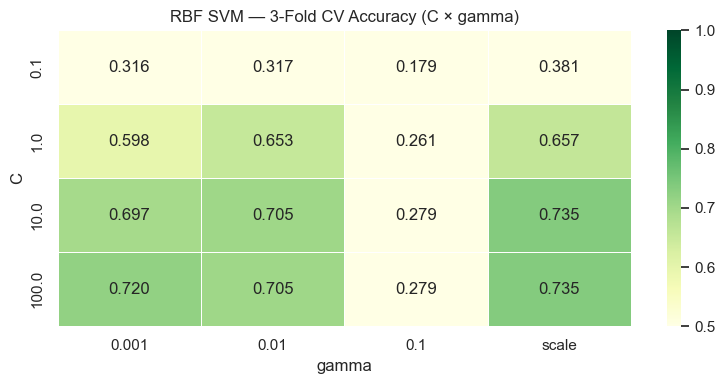

Saved to outputs/svm_rbf_grid.png


In [5]:
# Heatmap of CV accuracy over C x gamma
pivot = rbf_df.pivot(index='C', columns='gamma', values='cv_mean')

fig, ax = plt.subplots(figsize=(8, 4))
sns.heatmap(pivot, annot=True, fmt='.3f', cmap='YlGn', ax=ax,
            linewidths=0.5, vmin=0.5, vmax=1.0)
ax.set_title('RBF SVM — 3-Fold CV Accuracy (C × gamma)')
ax.set_xlabel('gamma')
ax.set_ylabel('C')
plt.tight_layout()
plt.savefig('../outputs/svm_rbf_grid.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved to outputs/svm_rbf_grid.png')

In [6]:
t0      = time.time()
rbf_svm = SVC(kernel='rbf', C=best_rbf['C'], gamma=best_rbf['gamma'],
              random_state=RANDOM_STATE)
rbf_svm.fit(X_train_s, y_train)
rbf_time = time.time() - t0

rbf_pred = rbf_svm.predict(X_test_s)
rbf_acc  = sk_acc(y_test, rbf_pred)
rbf_f1   = f1_score(y_test, rbf_pred, average='macro')

print(f'RBF SVM (C={best_rbf["C"]}, gamma={best_rbf["gamma"]})')
print(f'acc={rbf_acc:.3f}  macro-F1={rbf_f1:.3f}  train={rbf_time:.1f}s')
print()
print(classification_report(y_test, rbf_pred, labels=EMOTION_ORDER, target_names=EMOTION_ORDER))

RBF SVM (C=100.0, gamma=scale)
acc=0.839  macro-F1=0.835  train=0.4s

                 precision     recall   f1-score    support

        neutral       0.90       0.99       0.94         38
           calm       0.88       0.90       0.89         88
          happy       0.86       0.70       0.78         67
            sad       0.79       0.83       0.81         70
          angry       0.79       0.81       0.80         67
        fearful       0.82       0.87       0.85         82
        disgust       0.81       0.74       0.78         44
      surprised       0.85       0.83       0.84         35

       accuracy                             0.84        491
      macro avg       0.84       0.83       0.83        491


## 5. Polynomial Kernel — Hyperparameter Search

In [7]:
C_values_poly  = [0.1, 1, 10]
degree_values  = [2, 3, 4]

poly_results = []

for C in C_values_poly:
    for d in degree_values:
        clf    = SVC(kernel='poly', C=C, degree=d, gamma='scale', random_state=RANDOM_STATE)
        scores = cross_val_score(clf, X_train_s, y_train, cv=skf, scoring='accuracy')
        poly_results.append({'C': C, 'degree': d,
                              'cv_mean': scores.mean(), 'cv_std': scores.std()})
        print(f'C={C:5.1f}  degree={d}  cv={scores.mean():.3f} ± {scores.std():.3f}')

poly_df   = pd.DataFrame(poly_results).sort_values('cv_mean', ascending=False)
best_poly = poly_df.iloc[0]
print(f'\nBest poly params: C={best_poly["C"]}  degree={best_poly["degree"]}  '
      f'cv_acc={best_poly["cv_mean"]:.3f}')

C=  0.1  degree=2  cv=0.323 ± 0.025


C=  0.1  degree=3  cv=0.324 ± 0.019


C=  0.1  degree=4  cv=0.221 ± 0.011


C=  1.0  degree=2  cv=0.606 ± 0.016


C=  1.0  degree=3  cv=0.606 ± 0.004


C=  1.0  degree=4  cv=0.495 ± 0.008


C= 10.0  degree=2  cv=0.670 ± 0.009


C= 10.0  degree=3  cv=0.704 ± 0.009


C= 10.0  degree=4  cv=0.645 ± 0.007

Best poly params: C=10.0  degree=3.0  cv_acc=0.704


In [8]:
t0       = time.time()
poly_svm = SVC(kernel='poly', C=best_poly['C'], degree=int(best_poly['degree']),
               gamma='scale', random_state=RANDOM_STATE)
poly_svm.fit(X_train_s, y_train)
poly_time = time.time() - t0

poly_pred = poly_svm.predict(X_test_s)
poly_acc  = sk_acc(y_test, poly_pred)
poly_f1   = f1_score(y_test, poly_pred, average='macro')

print(f'Poly SVM (C={best_poly["C"]}, degree={int(best_poly["degree"])})')
print(f'acc={poly_acc:.3f}  macro-F1={poly_f1:.3f}  train={poly_time:.1f}s')
print()
print(classification_report(y_test, poly_pred, labels=EMOTION_ORDER, target_names=EMOTION_ORDER))

Poly SVM (C=10.0, degree=3)
acc=0.802  macro-F1=0.791  train=0.4s

                 precision     recall   f1-score    support

        neutral       0.83       0.96       0.89         38
           calm       0.93       0.85       0.89         88
          happy       0.76       0.73       0.74         67
            sad       0.89       0.76       0.82         70
          angry       0.71       0.82       0.76         67
        fearful       0.71       0.79       0.75         82
        disgust       0.81       0.66       0.72         44
      surprised       0.68       0.86       0.76         35

       accuracy                             0.80        491
      macro avg       0.79       0.80       0.79        491


## 6. Confusion Matrix — Best SVM Kernel

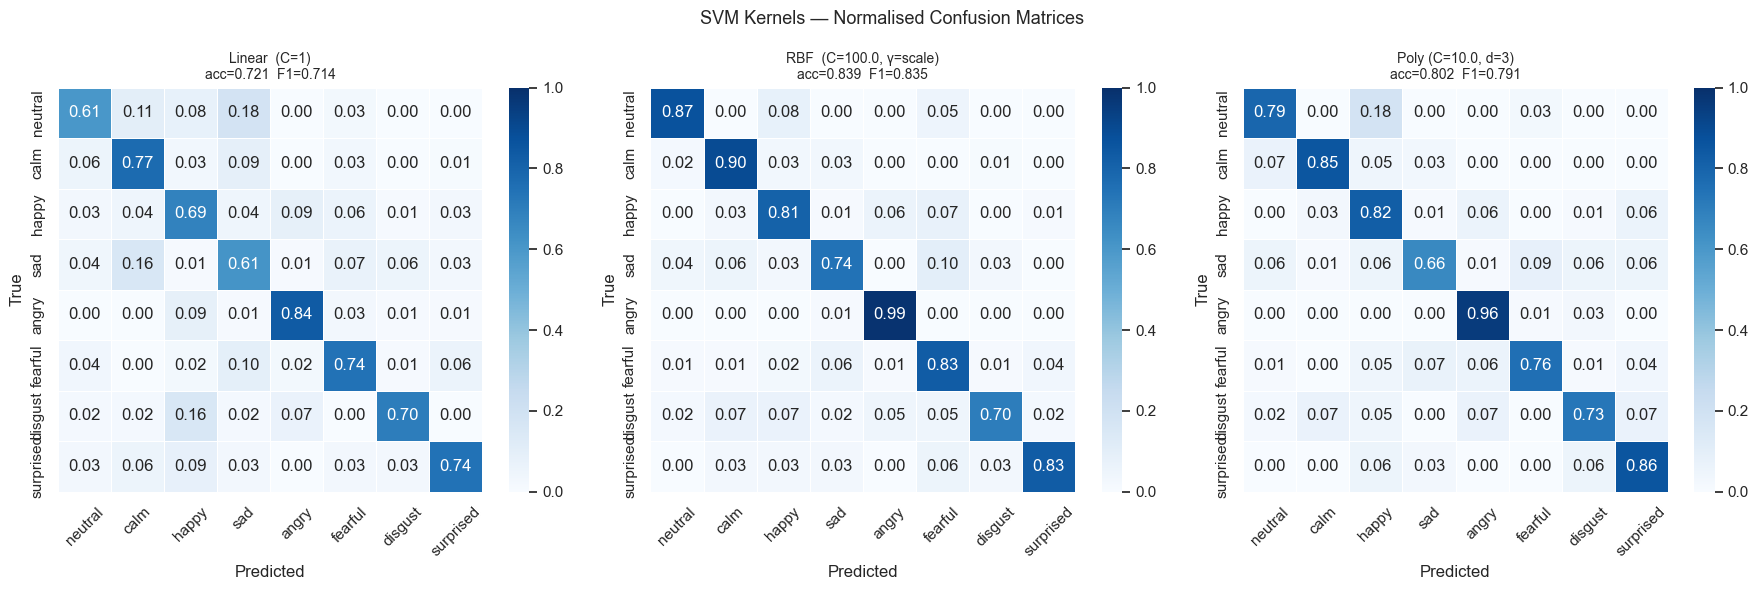

Saved to outputs/svm_confusion_matrices.png


In [9]:
kernel_results = {
    f'Linear  (C=1)':                       (lin_pred,  lin_acc,  lin_f1),
    f'RBF  (C={best_rbf["C"]}, γ={best_rbf["gamma"]})': (rbf_pred, rbf_acc, rbf_f1),
    f'Poly (C={best_poly["C"]}, d={int(best_poly["degree"])})': (poly_pred, poly_acc, poly_f1),
}

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
for ax, (name, (pred, acc, f1)) in zip(axes, kernel_results.items()):
    cm      = confusion_matrix(y_test, pred, labels=EMOTION_ORDER)
    cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)
    sns.heatmap(cm_norm, annot=True, fmt='.2f', cmap='Blues',
                xticklabels=EMOTION_ORDER, yticklabels=EMOTION_ORDER,
                ax=ax, vmin=0, vmax=1, linewidths=0.4)
    ax.set_title(f'{name}\nacc={acc:.3f}  F1={f1:.3f}', fontsize=10)
    ax.set_xlabel('Predicted')
    ax.set_ylabel('True')
    ax.tick_params(axis='x', rotation=45)

plt.suptitle('SVM Kernels — Normalised Confusion Matrices', fontsize=13)
plt.tight_layout()
plt.savefig('../outputs/svm_confusion_matrices.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved to outputs/svm_confusion_matrices.png')

## 7. Summary Comparison

In [10]:
summary = pd.DataFrame([
    {'Kernel': 'Linear', 'Best C': 1.0, 'Other': '—',
     'Test Acc': round(lin_acc, 3), 'Macro F1': round(lin_f1, 3), 'Train (s)': round(lin_time, 1)},
    {'Kernel': 'RBF', 'Best C': best_rbf['C'], 'Other': f'γ={best_rbf["gamma"]}',
     'Test Acc': round(rbf_acc, 3), 'Macro F1': round(rbf_f1, 3), 'Train (s)': round(rbf_time, 1)},
    {'Kernel': 'Polynomial', 'Best C': best_poly['C'], 'Other': f'd={int(best_poly["degree"])}',
     'Test Acc': round(poly_acc, 3), 'Macro F1': round(poly_f1, 3), 'Train (s)': round(poly_time, 1)},
])
print(summary.to_string(index=False))
print('\nContext: MLP (256-128) acc=0.804  |  LogReg acc=0.731')
summary

    Kernel  Best C   Other  Test Acc  Macro F1  Train (s)
    Linear     1.0       —     0.721     0.714        1.1
       RBF   100.0 γ=scale     0.839     0.835        0.4
Polynomial    10.0     d=3     0.802     0.791        0.4

Context: MLP (256-128) acc=0.804  |  LogReg acc=0.731


,Kernel,Best C,Other,Test Acc,Macro F1,Train (s)
0,Linear,1.0,—,0.721,0.714,1.1
1,RBF,100.0,γ=scale,0.839,0.835,0.4
2,Polynomial,10.0,d=3,0.802,0.791,0.4


## 8. Discussion

**Why does the RBF kernel outperform linear?**
Emotion is encoded in complex, non-linear combinations of spectral features.
The RBF kernel maps the 194-dimensional feature space to an infinite-dimensional
space where classes that are non-linearly separable in the original space become
linearly separable. The linear kernel can only find a hyperplane in the original
space and misses these interactions.

**Why does C matter?**
Small C allows more margin violations (softer boundary) — better generalisation
when features are noisy. Large C tries to classify every training point correctly,
which can lead to overfitting. The grid search identifies the best balance.

**Why does gamma matter for RBF?**
γ = `scale` (1 / (n_features × var(X))) is the sklearn default and usually a
good starting point. A very large γ makes each sample's influence vanishingly
small — the model overfit to individual points. A small γ makes the kernel
very smooth, approaching linear behaviour.

**SVM vs MLP?**
The best RBF SVM is competitive with logistic regression but still behind
the MLP. SVMs scale as O(n²) to O(n³) in training samples, making them
slower than the MLP's mini-batch gradient descent at larger dataset sizes.
However, SVMs have strong theoretical guarantees (margin maximisation) and
tend to work well with fewer samples.